In [3]:
!pip install psycopg2

  Preparing metadata (setup.py) ... one
  DEPRECATION: Building 'psycopg2' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'psycopg2'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for psycopg2: filename=psycopg2-2.9.11-cp313-cp313-linux_x86_64.whl size=170750 sha256=928bb04c8693e02533b6c8a4745eb0aa2b49372533a8c4815ebcc86b6765f4d4
  Stored in directory: /home/developer/.cache/pip/wheels/63/ed/1a/7f7f58e98cbe6623951e4308d81a93c8087d1ac9804513a056
Successfully built psycopg2


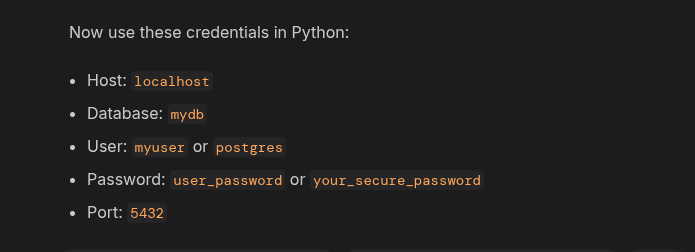

### `my_test_db` is name of database

In [3]:
import psycopg2

host = "localhost"
database = "my_test_db"
user = "postgres"
pas = "developer"
port="5432"
conn = psycopg2.connect(host=host, database=database, user=user, password=pas, port)
# your code here
cursor = conn.cursor()

In [20]:
import psycopg2

# Replace with your credentials
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)

cursor = conn.cursor()

# Create a table
create_table_query = '''
CREATE TABLE IF NOT EXISTS employees (
    id SERIAL PRIMARY KEY,
    name VARCHAR(100),
    department VARCHAR(50),
    salary REAL,
    hire_date DATE
);
'''

cursor.execute(create_table_query)
conn.commit()

print("Table created successfully.")

# Close connection
cursor.close()
conn.close()   

Table created successfully.


In [26]:
import psycopg2
# Replace with your credentials
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn.cursor()

# List all tables
cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema = 'public'
""")
tables = cursor.fetchall()

print("Tables in database:")
for table in tables:
    print(table[0])

# View data from your table
cursor.execute("SELECT * FROM employees;")
rows = cursor.fetchall()

print("\nData in 'employees' table:")
for row in rows:
    print(row)

# Close connection
cursor.close()
conn.close()   

Tables in database:
employees

Data in 'employees' table:


In [25]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)

cursor = conn.cursor()

# Query to list all tables in the 'public' schema
cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema = 'public' AND table_type = 'BASE TABLE';
""")

tables = cursor.fetchall()

print("Tables in 'public' schema:")
for table in tables:
    print(table[0])

cursor.close()
conn.close()   

Tables in 'public' schema:
employees


In [27]:
# Inserting into employees table
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)

cursor = conn.cursor()

# Insert a single row
cursor.execute("""
    INSERT INTO employees (name, department, salary, hire_date)
    VALUES (%s, %s, %s, %s)
""", ('Alice Smith', 'Engineering', 75000, '2025-01-15'))

# Commit the transaction
conn.commit()

print("Row inserted successfully.")

cursor.close()
conn.close()   

Row inserted successfully.


In [28]:
# Showing data of employees table
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)

cursor = conn.cursor()
# View data from your table
cursor.execute("SELECT * FROM employees;")
rows = cursor.fetchall()

print("\nData in 'employees' table:")
for row in rows:
    print(row)

# Close connection
cursor.close()
conn.close()   


Data in 'employees' table:
(1, 'Alice Smith', 'Engineering', 75000.0, datetime.date(2025, 1, 15))


In [1]:
import pandas as pd

In [8]:
df1 = pd.read_csv("data/accounts.csv")
df2 = pd.read_csv("data/products.csv")
df3 = pd.read_csv("data/transactions.csv")

In [9]:
# Creating accounts table
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)

cursor = conn.cursor()

# Create a table
create_table_query = '''
CREATE TABLE IF NOT EXISTS accounts (
    customer_id SERIAL PRIMARY KEY,
    first_name VARCHAR(100),
    last_name VARCHAR(100),
    address_1 VARCHAR(100),
    address_2 VARCHAR(100),
    city VARCHAR(50),
    state VARCHAR(50),
    zip_code INT,
    join_date DATE
);
'''

cursor.execute(create_table_query)
conn.commit()

print("Table created successfully.")

# Close connection
cursor.close()
conn.close()   

Table created successfully.


In [10]:
# Creating Products table
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)

cursor = conn.cursor()

# Create Table
create_table = """
CREATE TABLE IF NOT EXISTS products(
    product_code SERIAL PRIMARY KEY,
    product_id INT UNIQUE,
    product_description VARCHAR(100)

);
"""

cursor.execute(create_table)
conn.commit()

cursor.close()
conn.close()

In [29]:
df1
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  2 non-null      int64 
 1    first_name  2 non-null      object
 2    last_name   2 non-null      object
 3    address_1   2 non-null      object
 4    address_2   1 non-null      object
 5    city        2 non-null      object
 6    state       2 non-null      object
 7    zip_code    2 non-null      int64 
 8    join_date   2 non-null      object
dtypes: int64(2), object(7)
memory usage: 276.0+ bytes


In [31]:
df1

,customer_id,first_name,last_name,address_1,address_2,city,state,zip_code,join_date
0,4321,john,doe,1532 East Main St.,PO BOX 5,Middleton,Ohio,50045,2022/01/16
1,5677,jane,doe,543 Oak Rd.,NaN,BigTown,Iowa,84432,2021/05/07


In [41]:
df1
# df2.info()

,customer_id,first_name,last_name,address_1,address_2,city,state,zip_code,join_date
0,4321,john,doe,1532 East Main St.,PO BOX 5,Middleton,Ohio,50045,2022/01/16
1,5677,jane,doe,543 Oak Rd.,NaN,BigTown,Iowa,84432,2021/05/07


In [33]:
df2

,product_id,product_code,product_description
0,345,1,Widget Medium
1,241,2,Widget Large


In [11]:
df3

,transaction_id,transaction_date,product_id,product_code,product_description,quantity,account_id
0,AS345-ASDF-31234-FDAAD-9345,2022/06/01,345,1,Widget Medium,5,4321
1,9234A-JFDA-87654-BFAEA-0932,2022/06/02,241,2,Widget Large,1,5677


In [39]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   transaction_id        2 non-null      object
 1    transaction_date     2 non-null      object
 2    product_id           2 non-null      int64 
 3    product_code         2 non-null      int64 
 4    product_description  2 non-null      object
 5    quantity             2 non-null      int64 
 6    account_id           2 non-null      int64 
dtypes: int64(4), object(3)
memory usage: 244.0+ bytes


In [58]:
# Creating Products table
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)

cursor = conn.cursor()

create_table = """
CREATE TABLE transactions(
transaction_id VARCHAR(50) PRIMARY KEY,
transaction_date DATE,
amount
product_id INT NOT NULL REFERENCES products (product_id),
product_code INT ,
product_description VARCHAR(100),
quantity INT,
account_id INT NOT NULL REFERENCES accounts (customer_id)
);
"""

cursor.execute(create_table)
conn.commit()

# List all tables
cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema = 'public'
""")
tables = cursor.fetchall()

print("Tables in 'public' schema:")
for table in tables:
    print(table[0])

cursor.close()
conn.close()


Tables in 'public' schema:
employees
products
transaction
accounts


In [ ]:
transaction_id ,transaction_date,product_id ,product_code ,product_description,quantity ,account_id

In [63]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)

cursor = conn.cursor()

# Query to get column details
cursor.execute("""
    SELECT column_name, data_type, is_nullable
    FROM information_schema.columns
    WHERE table_name = %s
    ORDER BY ordinal_position;
""", ('transaction',))

print("Table schema:")
for row in cursor.fetchall():
    print(row)

cursor.close()
conn.close()   

Table schema:
('transaction_id', 'character varying', 'NO')
('transaction_date', 'date', 'YES')
('product_id', 'integer', 'NO')
('product_code', 'integer', 'YES')
('product_description', 'character varying', 'YES')
('quantity', 'integer', 'YES')
('account_id', 'integer', 'NO')


In [ ]:

# Ingest data from csv
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn.cursor()

# Ensure table exists with matching schema
with open('data/accounts.csv', 'r') as f:
    next(f)  # Skip header
    cursor.copy_from(f, 'accounts', sep=',')

conn.commit()
cursor.close()
conn.close()   

In [70]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn.cursor()

cursor.execute("SELECT * FROM accounts LIMIT 5")
rows = cursor.fetchall()

# Get column names
col_names = [desc.name for desc in cursor.description]

# Print with headers
print(col_names)
for row in rows:
    print(row)

cursor.close()
conn.close()   

['customer_id', 'first_name', 'last_name', 'address_1', 'address_2', 'city', 'state', 'zip_code', 'join_date']
(4321, ' john', ' doe', ' 1532 East Main St.', ' PO BOX 5', ' Middleton', ' Ohio', 50045, datetime.date(2022, 1, 16))
(5677, ' jane', ' doe', ' 543 Oak Rd.', '', 'BigTown', ' Iowa', 84432, datetime.date(2021, 5, 7))


In [71]:
# ======================

In [73]:

# Ingest data from 2nd csv to sql table
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn.cursor()

# Ensure table exists with matching schema
with open('data/products.csv', 'r') as f:
    next(f)  # Skip header
    cursor.copy_from(f, 'products', sep=',')

conn.commit()
cursor.close()
conn.close() 

In [74]:
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn.cursor()

cursor.execute("SELECT * FROM products")
rows = cursor.fetchall()

# Get column names
col_names = [desc.name for desc in cursor.description]

# Print with headers
print(col_names)
for row in rows:
    print(row)

cursor.close()
conn.close()   

['product_code', 'product_id', 'product_description']
(345, 1, ' Widget Medium')
(241, 2, ' Widget Large')


In [75]:
# ==================================================

In [76]:

# Ingest data from 2nd csv to sql table
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn.cursor()

# Ensure table exists with matching schema
with open('data/transactions.csv', 'r') as f:
    next(f)  # Skip header
    cursor.copy_from(f, 'transaction', sep=',')

conn.commit()
cursor.close()
conn.close() 

ForeignKeyViolation: insert or update on table "transaction" violates foreign key constraint "transaction_product_id_fkey"
DETAIL:  Key (product_id)=(345) is not present in table "products".


In [80]:
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn.cursor()

cursor.execute("SELECT * FROM transaction")
rows = cursor.fetchall()

# Get column names
col_names = [desc.name for desc in cursor.description]

# Print with headers
print(col_names)

cursor.close()
conn.close()   

['transaction_id', 'transaction_date', 'product_id', 'product_code', 'product_description', 'quantity', 'account_id']


In [81]:
pd.read_csv("data/transactions.csv").head()

,transaction_id,transaction_date,product_id,product_code,product_description,quantity,account_id
0,AS345-ASDF-31234-FDAAD-9345,2022/06/01,345,1,Widget Medium,5,4321
1,9234A-JFDA-87654-BFAEA-0932,2022/06/02,241,2,Widget Large,1,5677


In [8]:
# ===================================

In [42]:
import psycopg2

In [40]:
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn.cursor()

# Use PostgreSQL syntax to list databases
cursor.execute("SELECT datname FROM pg_database WHERE datistemplate = false;")
rows = cursor.fetchall()

# Get column names
column_names = [desc[0] for desc in cursor.description]

# Print with headers
print(column_names)
for row in rows:
    print(row[0])  # Each row is a tuple, so we access the first element

cursor.close()
conn.close()

['datname']
postgres
my_test_db
my_new_database
sales_data
newsales_data


In [ ]:
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn.cursor()

# Use PostgreSQL syntax to list databases
cursor.execute("SELECT datname FROM pg_database WHERE datistemplate = false;")
rows = cursor.fetchall()

# Get column names
column_names = [desc[0] for desc in cursor.description]

# Print with headers
print(column_names)
for row in rows:
    print(row[0])  # Each row is a tuple, so we access the first element

cursor.close()
conn.close()

In [41]:
conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="developer",
    port="5432"
)

# Create a cursor object
cursor = conn.cursor()

# Execute query to list all tables in the database
cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema='public'
""")

# Fetch and display all tables
tables = cursor.fetchall()
for table in tables:
    print(table[0])

# Close cursor and connection
cursor.close()
conn.close()

products
transactions
accounts


In [14]:
import pandas as pd

In [15]:
conn = psycopg2.connect(
    host="localhost",
    database="my_test_db",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn
# Create a cursor object
cursor = conn.cursor()

# First, get a list of all tables in the database
cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema='public'
""")

tables = [table[0] for table in cursor.fetchall()]
print("Tables in database:", tables)

# Function to display data from a specific table
def view_table_data(table_name):
    print(f"\nData in table '{table_name}':")
    
    # Execute query to get all data from the table
    cursor.execute(f"SELECT * FROM {table_name}")
    
    # Get column names
    col_names = [desc[0] for desc in cursor.description]
    
    # Fetch all rows
    rows = cursor.fetchall()
    
    # Create a DataFrame for better display
    df = pd.DataFrame(rows, columns=col_names)
    return df

# Example: View data from each table
for table in tables:
    print(view_table_data(table))

# Close cursor and connection
cursor.close()
conn.close()

Tables in database: ['employees', 'products', 'transaction', 'accounts']

Data in table 'employees':
   id         name   department   salary   hire_date
0   1  Alice Smith  Engineering  75000.0  2025-01-15

Data in table 'products':
   product_code  product_id product_description
0           345           1       Widget Medium
1           241           2        Widget Large

Data in table 'transaction':
Empty DataFrame
Columns: [transaction_id, transaction_date, product_id, product_code, product_description, quantity, account_id]
Index: []

Data in table 'accounts':
   customer_id first_name last_name            address_1  address_2  \
0         4321       john       doe   1532 East Main St.   PO BOX 5   
1         5677       jane       doe          543 Oak Rd.              

         city  state  zip_code   join_date  
0   Middleton   Ohio     50045  2022-01-16  
1     BigTown   Iowa     84432  2021-05-07  


# ===========================

In [32]:
import psycopg2
from psycopg2.extensions import ISOLATION_LEVEL_AUTOCOMMIT

# Connect to the default 'postgres' database to create a new database
conn = psycopg2.connect(
    host="localhost",
    database="postgres",  # Connect to default database
    user="postgres",
    password="developer",
    port="5432"
)

# Set autocommit mode for database creation
conn.set_isolation_level(ISOLATION_LEVEL_AUTOCOMMIT)

# Create a cursor object
cursor = conn.cursor()

# Define the name of the new database
new_db_name = "NewSales_Data"

# SQL command to create a new database
create_db_query = f"CREATE DATABASE {new_db_name};"

try:
    # Execute the create database command
    cursor.execute(create_db_query)
    print(f"Database '{new_db_name}' created successfully!")
except psycopg2.errors.DuplicateDatabase:
    print(f"Database '{new_db_name}' already exists.")
except Exception as e:
    print(f"Error creating database: {e}")
finally:
    # Close the cursor and connection
    cursor.close()
    conn.close()

✅ Database 'NewSales_Data' created successfully!


In [37]:
import psycopg2

def main(
        host="localhost",
        database="postgres",
        user="postgres",
         password="developer",
        port="5432"):

    try:
        # 1. Connect to PostgreSQL
        conn = psycopg2.connect(
            host=host,
            database=database,
            user=user,
            password=password,
            port=port
        )
        cursor = conn.cursor()
        print("Database connected.")

        # 2. Create all required tables (DDL)
        create_tables = """
        CREATE TABLE IF NOT EXISTS products (
            product_id INT PRIMARY KEY,
            product_code VARCHAR(10),
            product_description TEXT
        );

        CREATE TABLE IF NOT EXISTS accounts (
            customer_id INT PRIMARY KEY,
            first_name VARCHAR(50),
            last_name VARCHAR(50),
            address_1 TEXT,
            address_2 TEXT,
            city VARCHAR(50),
            state VARCHAR(50),
            zip_code VARCHAR(10),
            join_date DATE
        );

        DROP TABLE IF EXISTS transactions;

        CREATE TABLE transactions (
            transaction_id VARCHAR(50) PRIMARY KEY,
            transaction_date DATE,
            product_id INT REFERENCES products(product_id),
            product_code VARCHAR(10),
            product_description TEXT,
            quantity INT,
            account_id INT REFERENCES accounts(customer_id)
        );
        """
        cursor.execute(create_tables)
        print("Tables created.")

        # 3. Load CSV: products
        with open('data/products.csv', 'r') as file:
            next(file)  # Skip header
            cursor.copy_from(file, 'products', sep=',', null='')
        print("Products loaded.")

        # 4. Load CSV: accounts
        with open('data/accounts.csv', 'r') as file:
            next(file)
            cursor.copy_from(file, 'accounts', sep=',', null='')
        print("Accounts loaded.")

        # 5. Load CSV: transactions
        with open('data/transactions.csv', 'r') as file:
            next(file)
            cursor.copy_from(file, 'transactions', sep=',', null='')
        print("Transactions loaded.")

        # 6. Commit & close
        conn.commit()
        cursor.close()
        conn.close()
        print("DONE! Data ingested into PostgreSQL successfully.")

    except Exception as e:
        print("Error occurred:", e)



if __name__ == "__main__":
    main()

Database connected.
Tables created.
Error occurred: duplicate key value violates unique constraint "products_pkey"
DETAIL:  Key (product_id)=(345) already exists.
CONTEXT:  COPY products, line 1



In [13]:
conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="developer",
    port="5432"
)
cursor = conn
# Create a cursor object
cursor = conn.cursor()

# First, get a list of all tables in the database
cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema='public'
""")

tables = [table[0] for table in cursor.fetchall()]
print("Tables in database:", tables)

# Function to display data from a specific table
def view_table_data(table_name):
    print(f"\nData in table '{table_name}':")
    
    # Execute query to get all data from the table
    cursor.execute(f"SELECT * FROM {table_name}")
    
    # Get column names
    col_names = [desc[0] for desc in cursor.description]
    
    # Fetch all rows
    rows = cursor.fetchall()
    
    # Create a DataFrame for better display
    df = pd.DataFrame(rows, columns=col_names)
    return df

# Example: View data from each table
for table in tables:
    print(view_table_data(table))

# Close cursor and connection
cursor.close()
conn.close()

Tables in database: ['accounts']

Data in table 'accounts':
Empty DataFrame
Columns: [customer_id, first_name, last_name, address_1, address_2, city, state, zip_code, join_date]
Index: []


In [1]:
# =============

In [2]:
import os
import pandas as pd
import psycopg2


In [14]:
import os

import pandas as pd
import psycopg2


def create_table(query, cur, conn):
    cur.execute(query)
    conn.commit()


def main():
    host = "localhost"
    database = "postgres"
    user = "postgres"
    pas = "developer"
    conn = psycopg2.connect(host=host, database=database, user=user, password=pas)
    cur = conn.cursor()

    files_path = os.path.join(os.getcwd(), 'data')

    dtype_mapping = {
        "int64": "INTEGER",
        "object": "VARCHAR(100)",
    }
    for file in os.listdir(files_path):
        csv_path = os.path.join(files_path, file)
        if file.endswith('.csv'):
            df = pd.read_csv(csv_path)

            file_name = file.split('.')[0]
            create_table_columns = []

            for col, dtype in df.dtypes.items():
                type = dtype_mapping.get(str(dtype))
                create_table_columns.append(f"{col} {type}")

            query = f"DROP TABLE IF EXISTS products CASCADE; DROP TABLE IF EXISTS accounts CASCADE; DROP TABLE IF EXISTS transactions CASCADE; CREATE TABLE {file_name} ({', '.join(create_table_columns)});"

        create_table(query, cur, conn)


if __name__ == "__main__":
    main()

In [15]:
 host = "localhost"
database = "postgres"
user = "postgres"
pas = "developer"
conn = psycopg2.connect(host=host, database=database, user=user, password=pas)
cursor = conn.cursor()


# First, get a list of all tables in the database
cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema='public'
""")

tables = [table[0] for table in cursor.fetchall()]
print("Tables in database:", tables)

# Function to display data from a specific table
def view_table_data(table_name):
    print(f"\nData in table '{table_name}':")
    
    # Execute query to get all data from the table
    cursor.execute(f"SELECT * FROM {table_name}")
    
    # Get column names
    col_names = [desc[0] for desc in cursor.description]
    
    # Fetch all rows
    rows = cursor.fetchall()
    
    # Create a DataFrame for better display
    df = pd.DataFrame(rows, columns=col_names)
    return df

# Example: View data from each table
for table in tables:
    print(view_table_data(table))

# Close cursor and connection
cursor.close()
conn.close()

Tables in database: ['accounts']

Data in table 'accounts':
Empty DataFrame
Columns: [customer_id, first_name, last_name, address_1, address_2, city, state, zip_code, join_date]
Index: []


In [12]:
host = "localhost"
database = "postgres"
user = "postgres"
pas = "developer"
conn = psycopg2.connect(host=host, database=database, user=user, password=pas)
cursor = conn.cursor()
# First, get a list of all tables in the database
cursor.execute("""
    SELECT table_name 
    FROM information_schema.tables 
    WHERE table_schema='public'
""")

tables = [table[0] for table in cursor.fetchall()]
print("Tables in database:", tables)

# Function to display data from a specific table
def view_table_data(table_name):
    print(f"\nData in table '{table_name}':")
    
    # Execute query to get all data from the table
    cursor.execute(f"SELECT * FROM {table_name}")
    
    # Get column names
    col_names = [desc[0] for desc in cursor.description]
    
    # Fetch all rows
    rows = cursor.fetchall()
    
    # Create a DataFrame for better display
    df = pd.DataFrame(rows, columns=col_names)
    return df

# Example: View data from each table
for table in tables:
    print(view_table_data(table))

# Close cursor and connection
cursor.close()
conn.close()

Tables in database: ['accounts']

Data in table 'accounts':
Empty DataFrame
Columns: [customer_id, first_name, last_name, address_1, address_2, city, state, zip_code, join_date]
Index: []
